In [3]:
# https://drive.google.com/file/d/1Lz-3c8DNRTiBHvMn-8UY7SN8qu6mQ01r/view?usp=sharing
! gdown --id 1Lz-3c8DNRTiBHvMn-8UY7SN8qu6mQ01r

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:132: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1Lz-3c8DNRTiBHvMn-8UY7SN8qu6mQ01r
To: /content/CarPrice_Assignment.csv
100% 26.7k/26.7k [00:00<00:00, 46.3MB/s]


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('CarPrice_Assignment.csv')
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [6]:
df.drop(['car_ID', 'CarName', 'symboling', 'compressionratio', 'stroke'], axis=1, inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   fueltype        205 non-null    object 
 1   aspiration      205 non-null    object 
 2   doornumber      205 non-null    object 
 3   carbody         205 non-null    object 
 4   drivewheel      205 non-null    object 
 5   enginelocation  205 non-null    object 
 6   wheelbase       205 non-null    float64
 7   carlength       205 non-null    float64
 8   carwidth        205 non-null    float64
 9   carheight       205 non-null    float64
 10  curbweight      205 non-null    int64  
 11  enginetype      205 non-null    object 
 12  cylindernumber  205 non-null    object 
 13  enginesize      205 non-null    int64  
 14  fuelsystem      205 non-null    object 
 15  boreratio       205 non-null    float64
 16  horsepower      205 non-null    int64  
 17  peakrpm         205 non-null    int

In [8]:
df.describe()

,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,39.544167,476.985643,6.542142,6.886443,7988.852332
min,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,288.000000,6600.000000,49.000000,54.000000,45400.000000


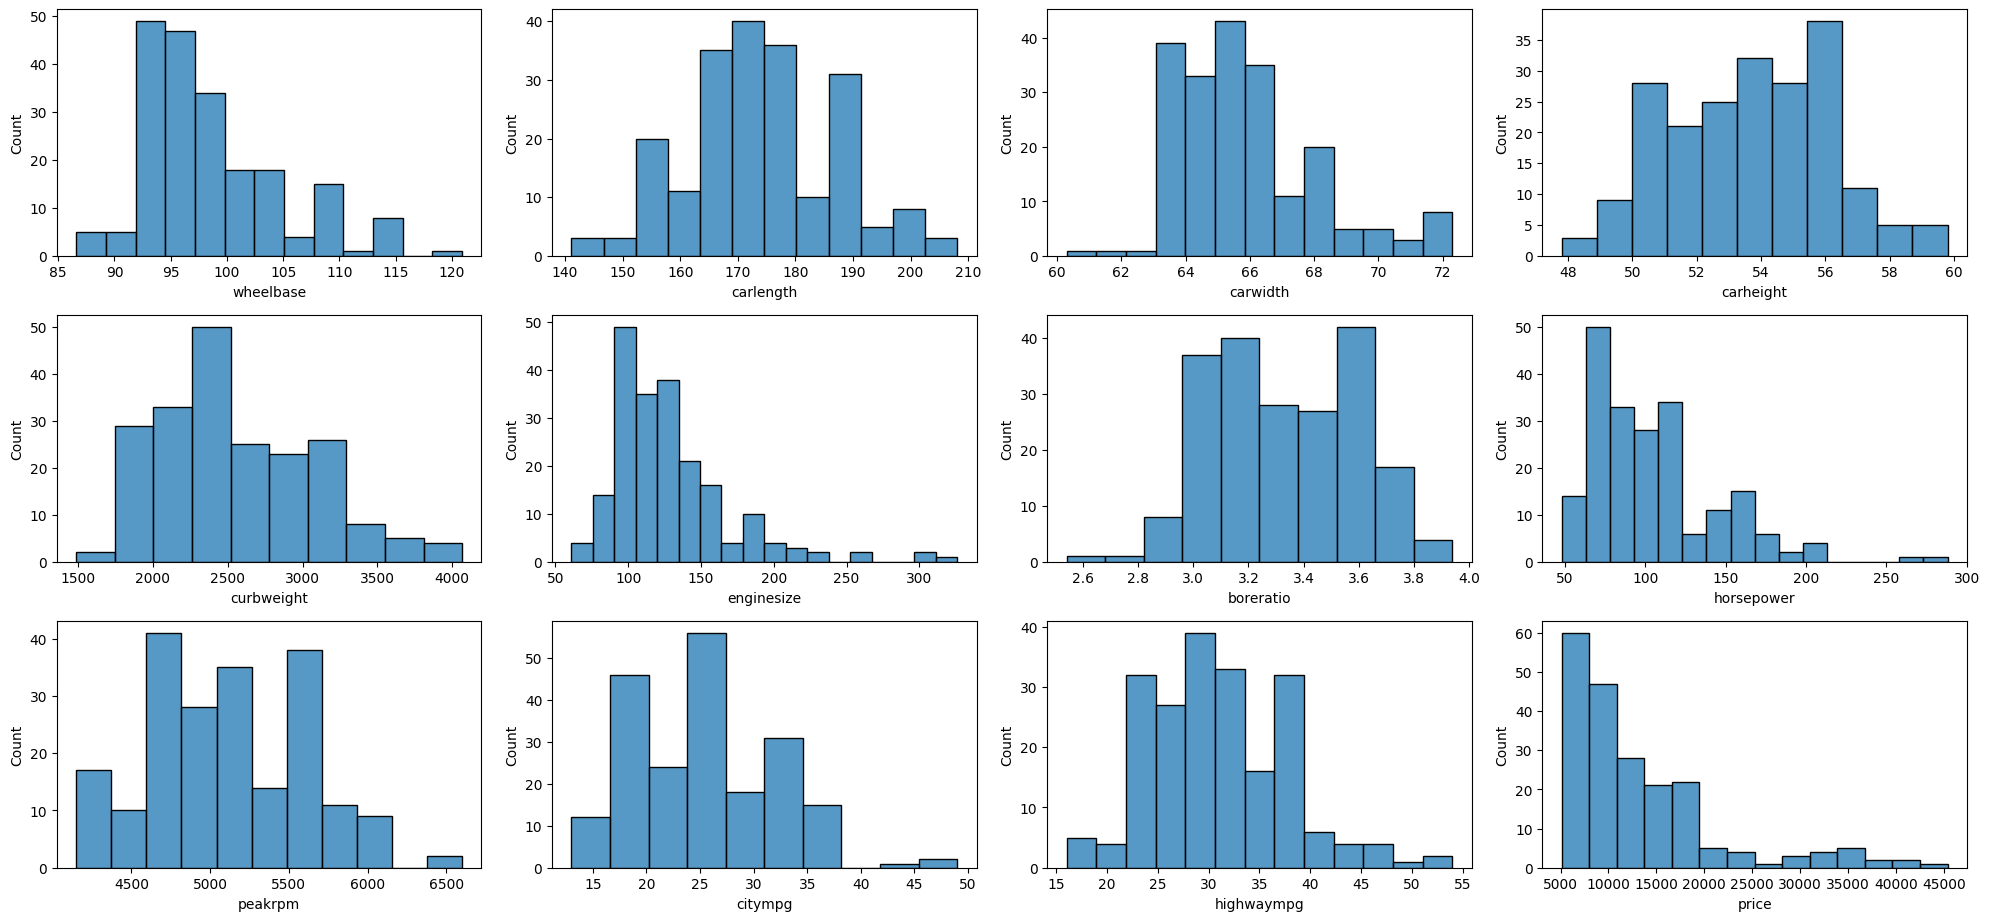

In [9]:
plt.figure(figsize = (20, 15))
plotnumber = 1
num_cols = [col for col in df.columns if df[col].dtype != 'object']

for column in num_cols:
    if plotnumber <= 14:
        ax = plt.subplot(5, 4, plotnumber)
        skewness = df[column].skew()
        sns.histplot(df[column])
        plt.xlabel(column)

    plotnumber += 1

plt.tight_layout()
plt.show()

In [10]:
cols = ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'fuelsystem',
       'enginetype', 'cylindernumber']
df = pd.get_dummies(df, columns=cols,drop_first = True)

In [11]:
df

,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,horsepower,peakrpm,citympg,...,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,cylindernumber_five,cylindernumber_four,cylindernumber_six,cylindernumber_three,cylindernumber_twelve,cylindernumber_two
0,88.6,168.8,64.1,48.8,2548,130,3.47,111,5000,21,...,False,False,False,False,False,True,False,False,False,False
1,88.6,168.8,64.1,48.8,2548,130,3.47,111,5000,21,...,False,False,False,False,False,True,False,False,False,False
2,94.5,171.2,65.5,52.4,2823,152,2.68,154,5000,19,...,False,False,True,False,False,False,True,False,False,False
3,99.8,176.6,66.2,54.3,2337,109,3.19,102,5500,24,...,True,False,False,False,False,True,False,False,False,False
4,99.4,176.6,66.4,54.3,2824,136,3.19,115,5500,18,...,True,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,109.1,188.8,68.9,55.5,2952,141,3.78,114,5400,23,...,True,False,False,False,False,True,False,False,False,False
201,109.1,188.8,68.8,55.5,3049,141,3.78,160,5300,19,...,True,False,False,False,False,True,False,False,False,False
202,109.1,188.8,68.9,55.5,3012,173,3.58,134,5500,18,...,False,False,True,False,False,False,True,False,False,False
203,109.1,188.8,68.9,55.5,3217,145,3.01,106,4800,26,...,True,False,False,False,False,False,True,False,False,False


<Axes: >

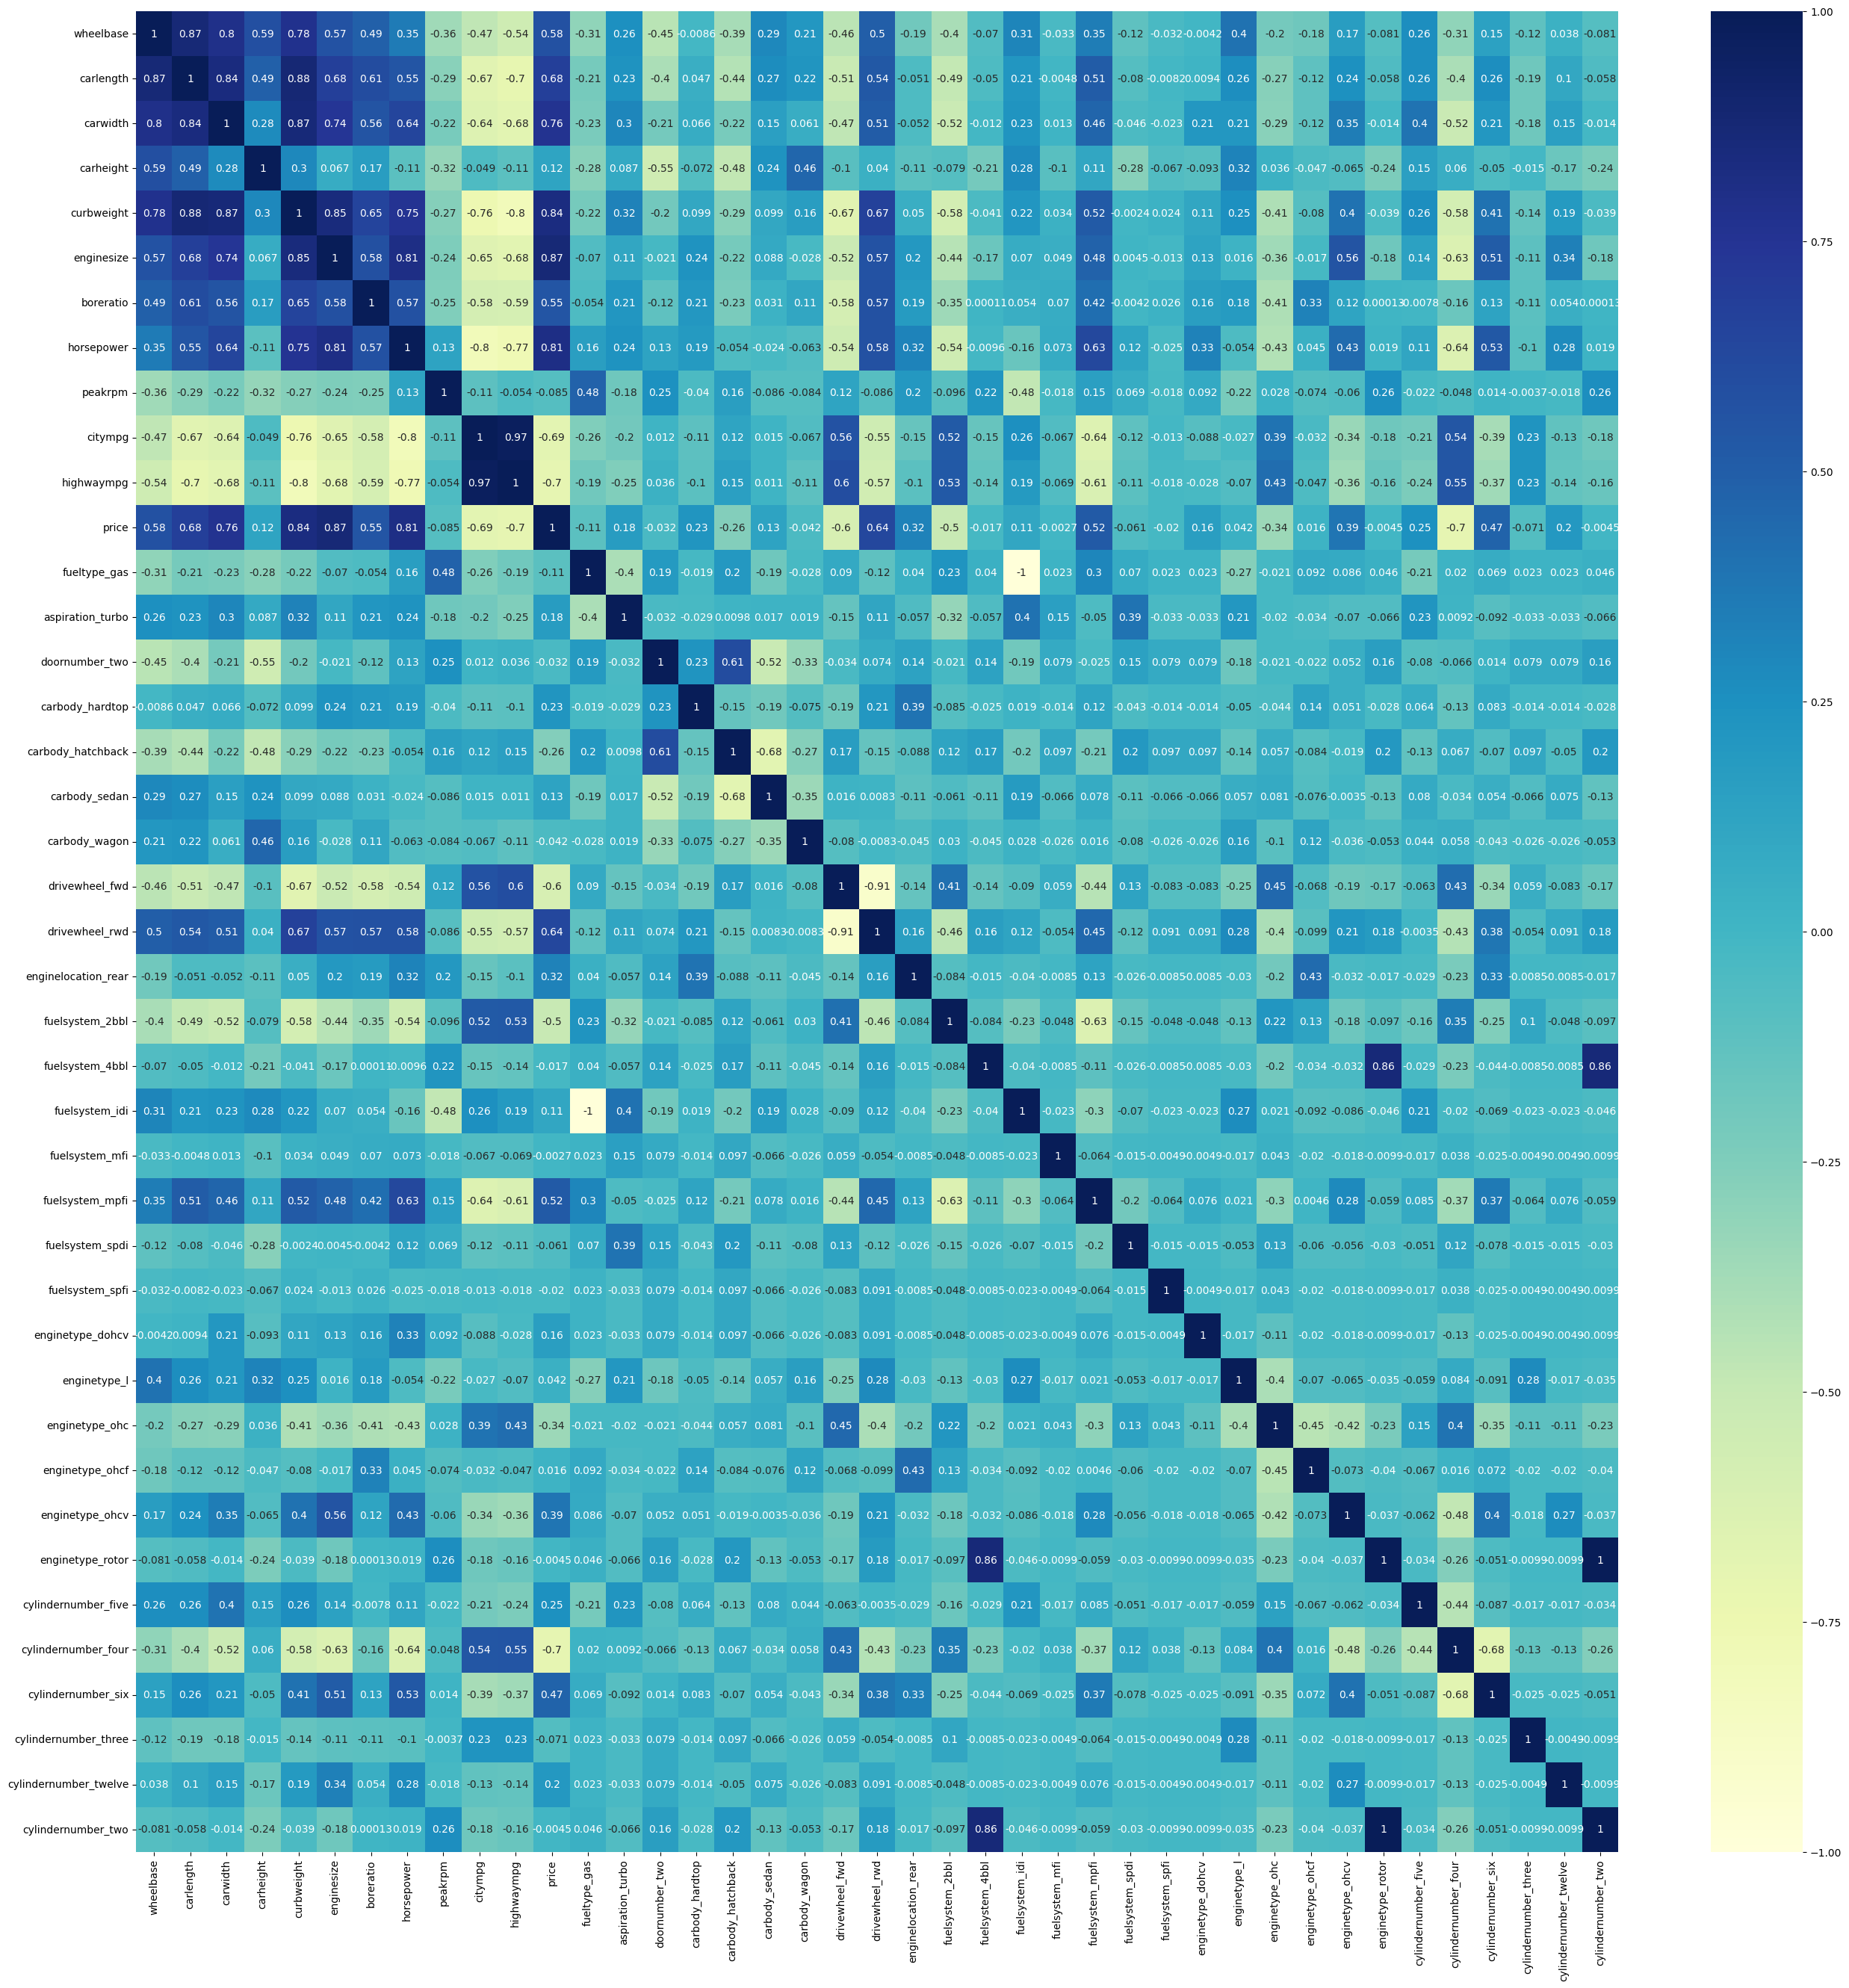

In [12]:
plt.figure(figsize=(32,32))
sns.heatmap(df.corr(), cmap="YlGnBu", annot=True)

In [13]:
X = df.drop('price',axis = 1 )
y = df['price']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =  train_test_split(X,y,train_size = 0.8 , shuffle=True, random_state = 42)

In [14]:
from sklearn.preprocessing import MinMaxScaler
mmc = MinMaxScaler()

X_train = mmc.fit_transform(X_train)
X_test = mmc.transform(X_test)
X_train

array([[0.63103448, 0.52413793, 0.40952381, ..., 0.        , 0.        ,
        0.        ],
       [0.73448276, 0.72586207, 0.62857143, ..., 0.        , 0.        ,
        0.        ],
       [0.3137931 , 0.43275862, 0.17142857, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.27241379, 0.35689655, 0.19047619, ..., 0.        , 0.        ,
        0.        ],
       [0.56206897, 0.67068966, 0.56190476, ..., 0.        , 0.        ,
        0.        ],
       [0.47586207, 0.68965517, 0.44761905, ..., 0.        , 0.        ,
        0.        ]])

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import ReLU ,PReLU , LeakyReLU , ELU
from tensorflow.keras.layers import Dropout

In [16]:
df.shape

(205, 41)

In [17]:
# creating a model using the Sequential API

model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation = tf.keras.activations.relu),
    tf.keras.layers.Dense(128, activation = tf.keras.activations.relu),
    tf.keras.layers.Dense(64, activation = tf.keras.activations.relu),
    tf.keras.layers.Dense(1)
])

# compiling the model
model.compile(loss = tf.keras.losses.mse, optimizer = tf.keras.optimizers.Adam(learning_rate = 0.05,), metrics = ['mae'] )

# fit the model
model_history = model.fit(X_train, y_train, epochs = 2000)

Epoch 1/2000
6/6 [==============================] - 3s 18ms/step - loss: 208877888.0000 - mae: 12091.6230
Epoch 2/2000
6/6 [==============================] - 0s 4ms/step - loss: 60592592.0000 - mae: 5791.0234
Epoch 3/2000
6/6 [==============================] - 0s 4ms/step - loss: 30671482.0000 - mae: 4370.1104
Epoch 4/2000
6/6 [==============================] - 0s 6ms/step - loss: 23108484.0000 - mae: 3750.6528
Epoch 5/2000
6/6 [==============================] - 0s 4ms/step - loss: 22732726.0000 - mae: 3690.1653
Epoch 6/2000
6/6 [==============================] - 0s 4ms/step - loss: 36151900.0000 - mae: 4769.5894
Epoch 7/2000
6/6 [==============================] - 0s 4ms/step - loss: 12292097.0000 - mae: 2665.1445
Epoch 8/2000
6/6 [==============================] - 0s 4ms/step - loss: 11457438.0000 - mae: 2298.3450
Epoch 9/2000
6/6 [==============================] - 0s 4ms/step - loss: 9674570.0000 - mae: 2132.3909
Epoch 10/2000
6/6 [==============================] - 0s 4ms/step - loss

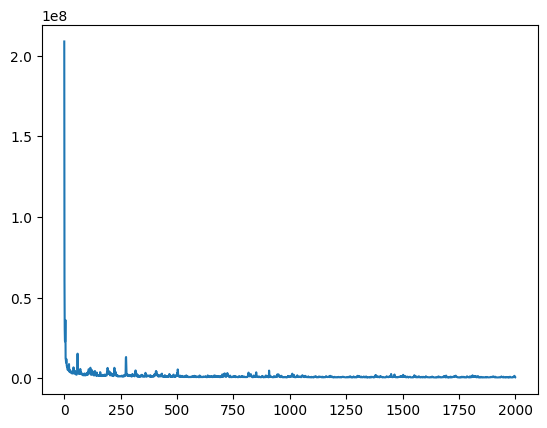

In [18]:
plt.plot(model_history.history['loss'])

In [19]:
from sklearn.metrics import mean_absolute_error, r2_score

In [20]:
mean_absolute_error(y_test, model.predict(X_test))

2/2 [==============================] - 0s 5ms/step


1393.1536952648628

1689.7688298994856  
1- 200
2 - 100
e-1500
lr- 0.005

1 - 256
2 - 128
3 - 64
e - 1500
lr - 0.005

In [ ]:
# 1613.8446370522104
# adam learning_rate = 0.01
# 256
# 128
# 64
# 1
# e - 1500
# loss - mse

In [21]:
r2_score(y_test, model.predict(X_test))

2/2 [==============================] - 0s 3ms/step


0.9544229699084942

In [22]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=200, criterion='absolute_error', random_state=42)
rf_model.fit(X_train, y_train)
mean_absolute_error(y_test, rf_model.predict(X_test))

1287.4062926829263

In [23]:
r2_score(y_test, rf_model.predict(X_test))

0.9558508803360555

In [24]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, max_depth=10, loss='absolute_error',random_state=42)
gb_model.fit(X_train, y_train)
mean_absolute_error(y_test, gb_model.predict(X_test))

1432.4896018098673

In [ ]:
r2_score(y_test, gb_model.predict(X_test))

0.941320769823677

In [25]:
!pip install optuna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.1/380.1 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.4/233.4 kB 10.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 7.5 MB/s eta 0:00:00


# Подберем параметры сети с помощью OPTUNA и обернем все в Pipeline

In [26]:
from sklearn.base import BaseEstimator, TransformerMixin

class NeuralNetworkTrainer(BaseEstimator, TransformerMixin):
    def __init__(self, epochs=50, learning_rate=0.01, units1=32, units2=32, units3=32, droupout_rate=0, verbose=0):
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.units1 = units1
        self.units2 = units2
        self.units3 = units3
        self.droupout_rate = droupout_rate
        self.verbose = verbose
        self.model = None

    def fit(self, X, y=None):
        input_shape = (X.shape[1],)  # Форма входных данных на основе X

        model = tf.keras.models.Sequential([
            tf.keras.layers.Dense(units=self.units1, activation='relu', input_shape=input_shape),
            tf.keras.layers.Dense(units=self.units2, activation='relu'),
            Dropout(rate=self.droupout_rate),
            tf.keras.layers.Dense(units=self.units3, activation='relu'),
            tf.keras.layers.Dense(units=1)
        ])

        optimizer = tf.keras.optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(optimizer=optimizer,
                      loss='mse',
                      metrics=['mse'])

        model.fit(X, y, epochs=self.epochs, verbose=self.verbose)
        self.model = model
        return self

    def transform(self, X):
        # NeuralNetworkTrainer не изменяет данные, поэтому просто возвращаем X
        return X

    def predict(self, X):
        # Предсказать метки классов для новых данных X
        if self.model is None:
            raise ValueError("Модель не обучена")
        y_pred = self.model.predict(X)
        return y_pred

    def score(self, X, y=None):
        # Оцените производительность модели на данных X и y
        if self.model is None:
            raise ValueError("Модель не обучена")
        y_pred = self.model.predict(X)
        mae = mean_absolute_error(y, y_pred)
        return mae

In [27]:
import optuna
from sklearn.pipeline import Pipeline
# Optuna параметры для нейронной сети
def objective(trial):
  param = {
      'epochs': trial.suggest_categorical('epochs', [500, 1000, 1500, 2000]),
      'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),
      'units1': trial.suggest_categorical('units1', [256, 512, 1024, 2048, 4096, 8192]),
      'units2': trial.suggest_categorical('units2', [128, 256, 512, 1024, 2048, 4096, 8192]),
      'units3': trial.suggest_categorical('units3', [64, 128, 256, 512, 1024, 2048, 4096, 8192]),
      # 'droupout_rate': trial.suggest_categorical('droupout_rate', [0, 0.01, 0.03, 0.05, 0.1, 0.15]),
      'verbose': trial.suggest_categorical('verbose', [0])
  }

  neural_network = NeuralNetworkTrainer(**param)
  # конвейер с нейронной сетью
  pipeline = Pipeline([
      ('neural_network', neural_network)
  ])

  pipeline.fit(X_train, y_train)
  val_mae = pipeline.score(X_train, y_train)

  return val_mae

In [28]:
study = optuna.create_study(direction='minimize')  # 'maximize' for accuracy, 'minimize' for loss
study.optimize(objective, n_trials=15)

[I 2024-06-21 13:45:50,445] A new study created in memory with name: no-name-45be8150-e019-4d2b-bd1d-34d6343838d2
<ipython-input-27-eed1507883aa>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),


6/6 [==============================] - 0s 2ms/step


[I 2024-06-21 13:47:13,201] Trial 0 finished with value: 648.8136403153583 and parameters: {'epochs': 2000, 'learning_rate': 0.013636647241683529, 'units1': 1024, 'units2': 512, 'units3': 8192, 'verbose': 0}. Best is trial 0 with value: 648.8136403153583.
<ipython-input-27-eed1507883aa>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),


6/6 [==============================] - 0s 2ms/step


[I 2024-06-21 13:47:34,471] Trial 1 finished with value: 1053.2558563976754 and parameters: {'epochs': 500, 'learning_rate': 0.02654312036012235, 'units1': 2048, 'units2': 128, 'units3': 64, 'verbose': 0}. Best is trial 0 with value: 648.8136403153583.
<ipython-input-27-eed1507883aa>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),


...

[I 2024-06-21 13:53:20,051] Trial 12 finished with value: 625.880889148247 and parameters: {'epochs': 1500, 'learning_rate': 0.018811777932807375, 'units1': 512, 'units2': 256, 'units3': 128, 'verbose': 0}. Best is trial 10 with value: 391.2753400104802.
<ipython-input-27-eed1507883aa>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),


6/6 [==============================] - 0s 2ms/step


[I 2024-06-21 13:54:25,352] Trial 13 finished with value: 1288.1367842511434 and parameters: {'epochs': 2000, 'learning_rate': 0.010094091031934893, 'units1': 8192, 'units2': 1024, 'units3': 2048, 'verbose': 0}. Best is trial 10 with value: 391.2753400104802.
<ipython-input-27-eed1507883aa>:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.05),


6/6 [==============================] - 0s 2ms/step


[I 2024-06-21 13:55:48,062] Trial 14 finished with value: 534.9829131335747 and parameters: {'epochs': 2000, 'learning_rate': 0.020097103721146318, 'units1': 512, 'units2': 4096, 'units3': 128, 'verbose': 0}. Best is trial 10 with value: 391.2753400104802.


**Параметры подобраны, запустим пайплайн обучения**

In [29]:
param = {
    'epochs': 2000, 'learning_rate': 0.020097103721146318, 'units1': 512, 'units2': 4096, 'units3': 128, 'verbose': 0
}

neural_network = NeuralNetworkTrainer(**param)
pipe = Pipeline([
    ('neural_network_trainer', neural_network)
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('neural_network_trainer',
                 NeuralNetworkTrainer(epochs=2000,
                                      learning_rate=0.020097103721146318,
                                      units1=512, units2=4096, units3=128))])

In [30]:
y_pred = pipe.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("MAE =", mae)

2/2 [==============================] - 0s 5ms/step
MAE = 1515.4397030297255
